<a href="https://colab.research.google.com/github/clleone/ds-20195-final/blob/main/clleone_ds_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q geopandas

In [45]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## US Maternal Mortality ##

A maternal death is defined by the World Health Organization as “the death of a woman while pregnant or within 42 days of termination of pregnancy, irrespective of the duration and the site of the pregnancy, from any cause related to or aggravated by the pregnancy or its management, but not from accidental or incidental causes”. Consequently, suicide is excluded from these statistics.

ICD 10 codes that are traditionally referenced in the construction of these statistics are:
- A34 (Obstetric Tetanus)
- O01-95
- O98-99

In [81]:
# CDC Wonder Underlying Cause of Death statistics 2018-2024 cumulative

# by state, cutting out disclaimer at bottom
matmort_by_state = pd.read_csv("/content/maternal-mort-by-state.csv")[:52]

# by county
matmort_by_county = pd.read_csv("/content/maternal-mort-by-county.csv")[:1475]
matmort_by_county['County Code'] = matmort_by_county['County Code'].astype('int').astype('string').str.zfill(5)
matmort_by_county_wlongstate = pd.read_csv("/content/maternal-mort-by-state-county.csv")[:1475]

# by race and ethnicity
matmort_by_race = pd.read_csv("/content/maternal-mort-by-race.csv")[:16]

# by five-year age cohort
matmort_by_age = pd.read_csv("/content/maternal-mort-by-5-year-age.csv")[:8]

In [24]:
# used these to figure out slicing indices
# matmort_by_age.loc[matmort_by_age['Notes'] == '---']
# matmort_by_age[:8]

Regions with at least one observation but fewer than 10 observations are included but "suppressed" in CDC Wonder Underlying Cause of Mortality datasets, but dataset totals include all observations. In some cases, regions with 10 or more observations are also suppressed if it makes it possible to back-calculate other values. Looking between the different datasets, we can see that at the state level there are 10 deaths total between suppressed states Delaware and Vermont.

In [16]:
# two states reported <10 maternal mortalities 2018-2024

matmort_by_state[matmort_by_state['Deaths'] == 'Suppressed']

,Notes,State,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
7,NaN,Delaware,10.0,Suppressed,3420621.0,Suppressed,Suppressed,Suppressed
45,NaN,Vermont,50.0,Suppressed,2215371.0,Suppressed,Suppressed,Suppressed


In [17]:
# suppressed county analysis, assuming 3007 counties total plus DC

suppressed_counties = len(matmort_by_county[matmort_by_county['Deaths'] == "Suppressed"])/3008 * 100
non_suppressed_counties = (len(matmort_by_county[matmort_by_county['Deaths'] != "Suppressed"]))/3008 * 100

print(f"{suppressed_counties:.2f}% of counties reported at least one but <10 maternal mortalities in 2018-2024.")
print(f"{non_suppressed_counties:.2f}% of counties reported 10 or more maternal mortalities in 2018-2024.")


44.85% of counties reported at least one but <10 maternal mortalities in 2018-2024.
4.19% of counties reported 10 or more maternal mortalities in 2018-2024.


In [18]:
national_total = int(matmort_by_state.iloc[-1, 3])
national_ns_total = matmort_by_state[(matmort_by_state['Deaths'] != 'Suppressed') & (matmort_by_state['Notes'] != 'Total')]['Deaths'].astype(int).sum()
# county_total = int(matmort_by_county.iloc[-1, 3])
county_ns_total = matmort_by_county[(matmort_by_county['Deaths'] != 'Suppressed') & (matmort_by_county['Notes'] != 'Total')]['Deaths'].astype(int).sum()
county_ns_total_2 = matmort_by_county_wlongstate[matmort_by_county_wlongstate['Deaths'] != 'Suppressed']['Deaths'].astype(int).sum()
(national_total, national_ns_total, county_ns_total, county_ns_total_2)

(5597, np.int64(5587), np.int64(2580), np.int64(2580))

In [94]:
matmort_by_county['GEOID'] = matmort_by_county['County Code']

In [95]:
matmort_by_county.head()

,Notes,County,County Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,GEOID
0,NaN,"Autauga County, AL",01001,Suppressed,183380,Suppressed,Suppressed,Suppressed,01001
1,NaN,"Baldwin County, AL",01003,Suppressed,673219,Suppressed,Suppressed,Suppressed,01003
2,NaN,"Barbour County, AL",01005,Suppressed,75775,Suppressed,Suppressed,Suppressed,01005
3,NaN,"Bibb County, AL",01007,Suppressed,71809,Suppressed,Suppressed,Suppressed,01007
4,NaN,"Blount County, AL",01009,Suppressed,174393,Suppressed,Suppressed,Suppressed,01009


In [82]:
us_counties = gpd.read_file("/content/tl_2025_us_county.zip")

In [115]:
counties_w_matmort_gdf = us_counties.merge(matmort_by_county, how='left', on='GEOID')

In [116]:
counties_w_matmort_gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,INTPTLON,geometry,Notes,County,County Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,...,-098.9816168,"POLYGON ((-98.95506 35.11643, -98.94903 35.116...",NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,...,-097.1232229,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351...",NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,...,-079.3396193,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418...",NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,...,-104.2616192,"POLYGON ((-104.98078 30.62552, -104.98073 30.6...",NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,...,-083.8948943,"POLYGON ((-84.10668 39.68891, -84.10662 39.689...",NaN,"Greene County, OH",39057,Suppressed,542657,Suppressed,Suppressed,Suppressed


In [117]:
from numpy import nan
def convert_suppressed_to_ones(deaths):
  if deaths == 'Suppressed':
    return 1
  elif nan:
    return 0
  else:
    return int(deaths)

counties_w_matmort_gdf['Deaths'] = counties_w_matmort_gdf['Deaths'].apply(convert_suppressed_to_ones)

In [118]:
def has_matmort(deaths):
  if deaths == 0:
    return 0
  else:
    return 1

counties_w_matmort_gdf['has_matmort'] = counties_w_matmort_gdf['Deaths'].apply(has_matmort)

In [119]:
# counties_w_matmort_gdf = counties_w_matmort_gdf[~counties_w_matmort_gdf['GEOID'].isin(['02013', '02016'])]

# dropping Puerto Rico because no mortality data
counties_w_matmort_gdf = counties_w_matmort_gdf[counties_w_matmort_gdf['STATEFP'] != '72']
# temporarily dropping Alaska and Hawaii, will insert as insets later
counties_w_matmort_gdf = counties_w_matmort_gdf[~counties_w_matmort_gdf['STATEFP'].isin(['02', '15'])]
counties_w_matmort_gdf = counties_w_matmort_gdf[counties_w_matmort_gdf['STATEFP'].astype(int) <= 56]

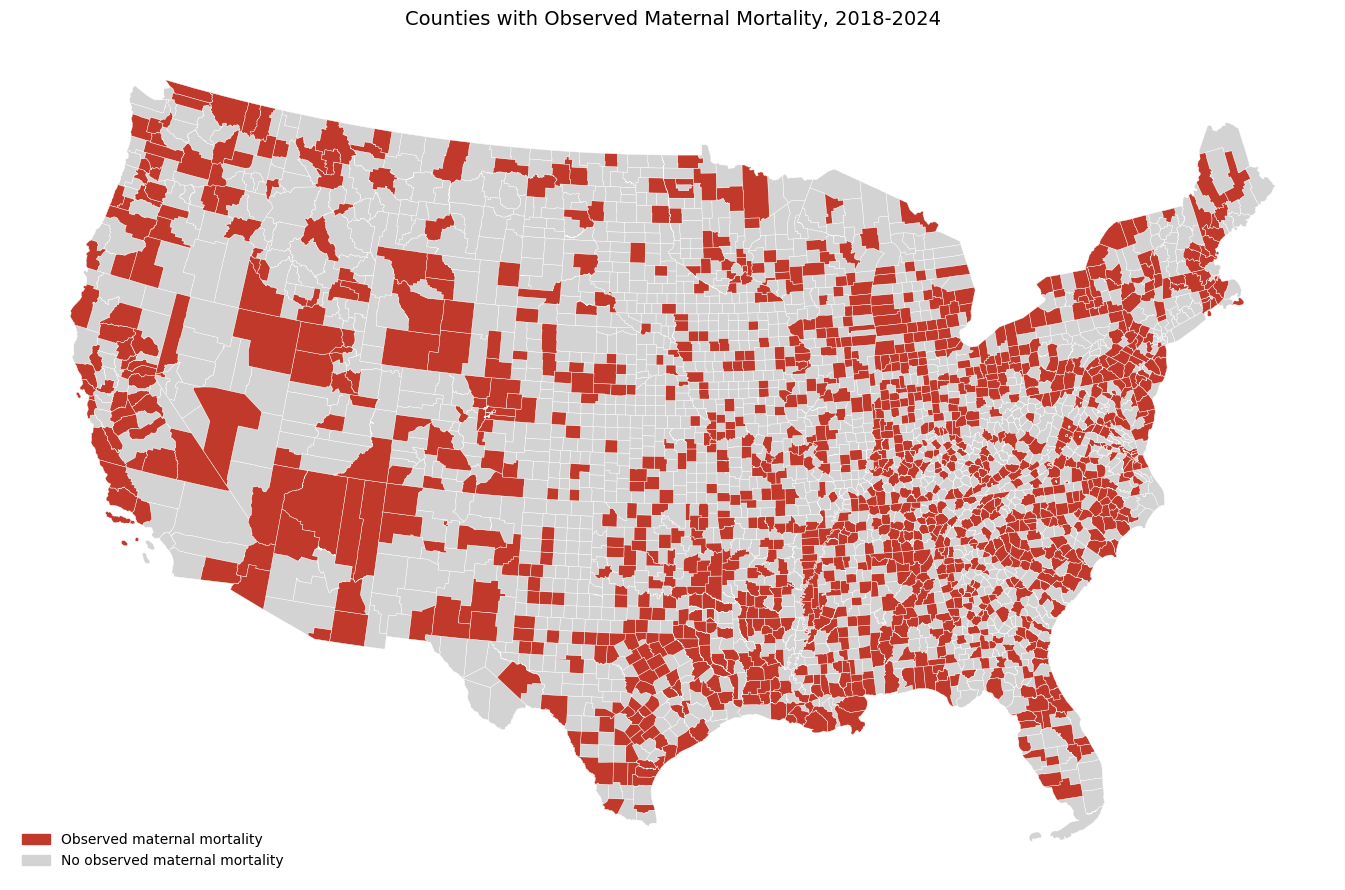

In [121]:
import matplotlib.patches as mpatches
counties_w_matmort_gdf = counties_w_matmort_gdf.to_crs("EPSG:5070")

fig, ax = plt.subplots(1, 1, figsize=(15, 9))

counties_w_matmort_gdf.plot(ax=ax, color="none", edgecolor="none")

counties_w_matmort_gdf[counties_w_matmort_gdf["has_matmort"] == 0].plot(
    ax=ax,
    color="#d3d3d3",
    edgecolor="white",
    linewidth=0.3
)
counties_w_matmort_gdf[counties_w_matmort_gdf["has_matmort"] == 1].plot(
    ax=ax,
    color="#c0392b",
    edgecolor="white",
    linewidth=0.3
)

# Legend
legend_handles = [
    mpatches.Patch(color="#c0392b", label="Observed maternal mortality"),
    mpatches.Patch(color="#d3d3d3", label="No observed maternal mortality"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=10)

ax.set_title("Counties with Observed Maternal Mortality, 2018-2024", fontsize=14, pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()

In [126]:
# urbanization analysis of counties represented
nchs_classifications = pd.read_csv('/content/NCHS-Urban-Rural-Classification.csv')
nchs_classifications['Location'] = nchs_classifications['Location'].astype(str).str.zfill(5)
nchs_classifications['GEOID'] = nchs_classifications['Location']

In [128]:
matmort_by_county = matmort_by_county.merge(nchs_classifications[['GEOID', '2023 Code']], how='left', on='GEOID')
matmort_by_county['urban_lvl'] = matmort_by_county['2023 Code'].str[3:]

In [133]:
matmort_by_urbanlvl = matmort_by_county.value_counts('2023 Code').sort_index()

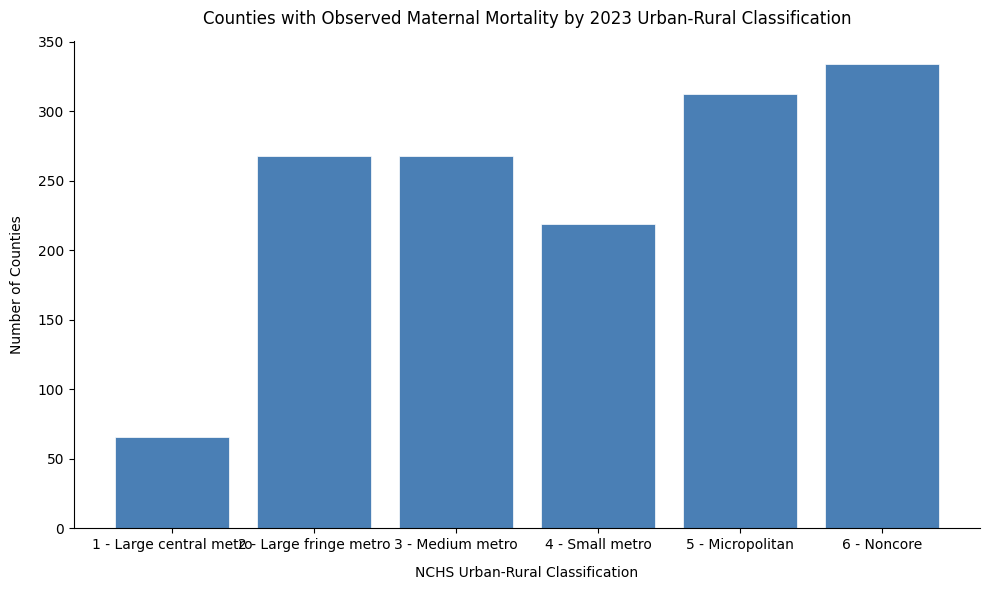

In [134]:
# will probably redo this plot with some kind of normalization

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    matmort_by_urbanlvl.index,
    matmort_by_urbanlvl.values,
    color="#4a7fb5",
    edgecolor="white",
    linewidth=0.5
)

ax.set_xlabel("NCHS Urban-Rural Classification", labelpad=10)
ax.set_ylabel("Number of Counties", labelpad=10)
ax.set_title("Counties with Observed Maternal Mortality by 2023 Urban-Rural Classification", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Seeing as maternal mortality is a relatively infrequent event (although the US still has the highest rate of developed nations), instead of normalizing by population, maternal mortality rates are typically calculated as the number of maternal deaths per 100,000 live births.

In [136]:
# CDC Wonder Natality statistics 2018-2024 cumulative

# by state, cutting out disclaimer at bottom
natal_by_state = pd.read_csv("/content/natal_by_state.csv")

# by county
natal_by_county = pd.read_csv("/content/natal-by-state-county.csv")

# by race and ethnicity
natal_by_race = pd.read_csv("/content/natal-by-race-ethnicity.csv")

# by five-year** age cohort
natal_by_age = pd.read_csv("/content/natal-by-age-cohort.csv")

In [140]:
natal_by_age.head()

,Notes,Age of Mother 10,Age of Mother 10 Code,Births
0,NaN,15 - 17 years,15-17,265102.0
1,NaN,18 - 19 years,18-19,813498.0
2,NaN,20-24 years,20-24,4612051.0
3,NaN,25-29 years,25-29,7216780.0
4,NaN,30-34 years,30-34,7694265.0


## US Maternal Healthcare Access ##

In [2]:
medical_structures = gpd.read_file("path/to/your_file.geojson")

In [18]:
medical_structures.columns

Index(['OBJECTID', 'PERMANENT_IDENTIFIER', 'SOURCE_FEATUREID',
       'SOURCE_DATASETID', 'SOURCE_DATADESC', 'SOURCE_ORIGINATOR',
       'DATA_SECURITY', 'DISTRIBUTION_POLICY', 'LOADDATE', 'FTYPE', 'FCODE',
       'NAME', 'ISLANDMARK', 'POINTLOCATIONTYPE', 'ADMINTYPE',
       'ADDRESSBUILDINGNAME', 'ADDRESS', 'CITY', 'STATE', 'ZIPCODE', 'GNIS_ID',
       'FOOT_ID', 'COMPLEX_ID', 'GLOBALID', 'geometry'],
      dtype='object')

In [20]:
AHRF = pd.read_csv("/content/AHRF2025.csv")

/tmp/ipykernel_4803/1477616603.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  AHRF = pd.read_csv("/content/AHRF2025.csv")


In [ ]:
AHRF_provider = pd.read_csv("/content/AHRF2025hp.csv")

In [28]:
AHRF_provider = pd.read_csv("/content/AHRF2025hp.csv")

In [32]:
AHRF_provider[AHRF_provider['apn_midwvs_npi_24'] > 0]

,fips_st_cnty,cnty_name_st_abbrev,phys_nf_prim_care_pc_exc_rsdt_23,phys_nf_prim_care_pc_exc_rsdt_22,phys_nf_prim_care_pc_rsdnt_23,phys_nf_prim_care_pc_rsdnt_22,md_nf_prim_care_pc_excl_rsdnt_23,md_nf_prim_care_pc_excl_rsdnt_22,md_nf_prim_care_pc_rsdnt_23,md_nf_prim_care_pc_rsdnt_22,...,tot_md_do_plas_surg_23,tot_md_do_anat_path_23,tot_md_do_pulm_dis_23,tot_md_do_radlgy_23,tot_md_do_rad_oncolgy_23,tot_md_do_thor_surg_23,tot_md_do_transpl_surg_23,tot_md_do_urolgy_23,tot_md_do_unspec_23,tot_md_do_vasc_med_23
0,1001,"Autauga, AL",22.0,25.0,1.0,1.0,21.0,24.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1003,"Baldwin, AL",172.0,160.0,64.0,55.0,151.0,144.0,50.0,41.0,...,5.0,11.0,8.0,5.0,2.0,2.0,0.0,8.0,7.0,0.0
10,1021,"Chilton, AL",11.0,11.0,1.0,1.0,11.0,11.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,1055,"Etowah, AL",82.0,78.0,14.0,5.0,75.0,71.0,11.0,4.0,...,1.0,2.0,6.0,0.0,2.0,2.0,0.0,6.0,3.0,0.0
34,1069,"Houston, AL",110.0,92.0,42.0,36.0,99.0,85.0,35.0,29.0,...,3.0,8.0,7.0,6.0,5.0,4.0,0.0,10.0,16.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3204,72099,"Moca, PR",17.0,18.0,0.0,0.0,17.0,18.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0
3218,72127,"San Juan, PR",593.0,620.0,114.0,95.0,593.0,620.0,114.0,95.0,...,18.0,55.0,39.0,34.0,8.0,9.0,0.0,41.0,231.0,0.0
3232,78010,"St. Croix, VI",15.0,15.0,0.0,0.0,12.0,12.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3233,78020,"St. John, VI",1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Planned layout:

Mortality

Quick definition of what's included according to WHO definition

Do summary stats of mort by state, by age group, by race/ethnicity.

Maybe take quick look at 2021 compared to other years.

Analysis of suppressed areas, what pct are rural? How do we know it's just not enough people? Compare live births, compare number of physicians.

Maybe revisit with expanded definition.

Maternal Care Access

Obstetric professionals per female reproductive age people

Learn more about HPSAs and MCTAs.
Isomorphs, think about what would be a sensible unit of analysis.

## Distance Analysis ##

Start with straight line distance.

Look at Census units with population, create centroids with population attached, calculate nearest facility, calculate nearest comparable institution (school or library maybe), divide by distance to that, split into urbanization categories, take averages, bar chart.